# Notebook de reproducibilidad — Sección 6

**Paper Amafore-ITAM 2026 · Equipo Datos México**

Este notebook reproduce de extremo a extremo la ruta
**microdatos ENOE → matrices de transición anuales → corrida del motor → figuras**
que respalda la Sección 6 del paper. Orquesta los scripts versionados del repo —
no reimplementa lógica: cada paso importa e invoca el módulo que produjo el
artefacto citado.

**Cómo usarlo**

1. Clona el repo e instala dependencias:
   `pip install --require-hashes -r requirements-dev.txt` y
   `pip install -e . --no-deps` (mismo procedimiento que el CI).
2. Abre el notebook desde `analisis/matrices/` — el kernel debe tener ese
   directorio de trabajo (es el comportamiento por defecto de Jupyter al abrir
   el archivo).
3. Ejecuta las celdas en orden. El **modo ligero** (flags por defecto) corre en
   ~1 minuto sin red. Las celdas **costosas** (descarga de microdatos, corrida
   completa 100k × 5 semillas) están apagadas por defecto y marcadas; se activan
   con los flags de la celda de configuración.


## 1. Contexto y mapa del pipeline

| # | Etapa | Código versionado | Insumo | Artefacto versionado que produce |
|---|-------|-------------------|--------|----------------------------------|
| 1 | Descarga de microdatos | `descarga_enoe.py` (parametrizado, §2) | API Datos México, tabla `sdem` ENOE | pickles locales por trimestre (gitignorados, regenerables) |
| 2 | Matrices anuales 5×5 | `estimador_matrices_anuales.py` | pickles sdem 2015–2024 | `matrices_anuales_2015_2024.csv`, `sensibilidad_kappa_anuales.csv`, `README_matrices_anuales.md` |
| 3 | Perfiles y tensor | `carga_matrices.py`, `asignacion_perfiles.py` | matrices CSV + `marginal_escolaridad_2024T3.csv` | tensor (8×2×3×5×5) en memoria |
| 4 | Motor de microsimulación | `motor/motor.py` (`simular`) | CSVs de `motor/data` + tensor | — (consumido por 5 y 6) |
| 5 | Corrida citable del paper | `corrida_final_paper.py` | motor heterogéneo, 100k × 5 semillas | `resultados_finales/*.csv` y `*.png` |
| 6 | Validación y anclaje | `motor/validacion.py`, `revalidacion_brecha1.py`, `auditoria_anclaje.py`, `cierre_anclaje.py` | corridas del motor | `revalidacion_brecha1.csv`, `auditoria_anclaje.csv`, `resultados_finales/checks_consistencia.csv` |

La cadena de dependencias es lineal: cada etapa consume exclusivamente artefactos
versionados o regenerables de la etapa anterior. Por eso el notebook puede
verificar cualquier eslabón contra su artefacto versionado aunque las etapas
costosas estén apagadas.


In [1]:
import contextlib
import io
import logging
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

AQUI = Path.cwd()
assert AQUI.name == "matrices", (
    "ejecuta el notebook con directorio de trabajo analisis/matrices/"
)
REPO = AQUI.parents[1]
for _p in (str(REPO), str(AQUI)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
logging.disable(logging.WARNING)  # mismo silenciado que los scripts de corrida

# ---- Flags de ejecución (modo ligero por defecto) --------------------------
EJECUTAR_DESCARGA = False          # §2: COSTOSA, ~1 h (36 trimestres ENOE vía API)
EJECUTAR_ESTIMACION = False        # §3: requiere los pickles de la §2
EJECUTAR_CORRIDA_COMPLETA = False  # §4: 100k agentes × 5 semillas (~4 min)

RESULTADOS = AQUI / "resultados_finales"
SALIDA_LIGERA = REPO / "motor" / "outputs"  # gitignorado: no toca artefactos
SALIDA_LIGERA.mkdir(exist_ok=True)

commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, cwd=REPO, check=False,
).stdout.strip() or "(sin git)"
print(f"repo: {REPO.name} · commit: {commit}")
print(f"modo: {'COMPLETO' if EJECUTAR_CORRIDA_COMPLETA else 'ligero'}")


repo: datos-mexico-py · commit: 8d2cfa2
modo: ligero


## 2. Descarga de microdatos ENOE

> ⚠️ **CELDA COSTOSA (~1 hora).** Descarga ~36 trimestres de la tabla `sdem`
> vía la API de Datos México (32 entidades en paralelo por trimestre, ~600 mil
> filas por trimestre). **Sáltala si ya tienes los pickles `sdem_*_v3.pkl` en
> `analisis/matrices/`** — la celda detecta el cache y `descarga_trimestre` es
> idempotente (no re-descarga lo que ya existe). Para ejecutarla pon
> `EJECUTAR_DESCARGA = True` en la celda de configuración y vuelve a correr
> desde ahí.

La descarga reutiliza `descarga_enoe.py` **parametrizado**: se agrega la columna
`n_ent` (número de entrevista, necesaria para armar el par anual 1ª↔5ª) y la
versión de cache se etiqueta `v3`, que es la que consume el estimador. El
universo de trimestres se deriva del propio estimador (los 27 pares (t, t+4)
con exclusión COVID) más `2025T1`, el benchmark transversal de
`cierre_anclaje.py` y `auditoria_anclaje.py`.


In [2]:
import descarga_enoe
from estimador_matrices_anuales import CACHE_PANEL, PARES_T, mas_4_trimestres

periodos = sorted({t for par in PARES_T for t in (par, mas_4_trimestres(par))})
periodos.append("2025T1")

descarga_enoe.VERSION = "v3"
if "n_ent" not in descarga_enoe.KEEP:
    descarga_enoe.KEEP.append("n_ent")

faltantes = [t for t in periodos if not (AQUI / f"sdem_{t}_v3.pkl").exists()]
print(f"trimestres requeridos: {len(periodos)} · sin cache local: {len(faltantes)}")
print(f"cache del panel apilado ({CACHE_PANEL.name}): "
      f"{'presente' if CACHE_PANEL.exists() else 'ausente'}")

if EJECUTAR_DESCARGA:
    for t in faltantes:
        descarga_enoe.descarga_trimestre(t)
    print("descarga completa")
elif faltantes:
    print("modo ligero: la §3 verifica contra el artefacto versionado, "
          "que no requiere microdatos locales")


trimestres requeridos: 36 · sin cache local: 36
cache del panel apilado (panel_apilado_2015_2024.pkl): ausente
modo ligero: la §3 verifica contra el artefacto versionado, que no requiere microdatos locales


## 3. Estimación de matrices de transición anuales (5×5)

El estimador (`estimador_matrices_anuales.py`) apila los 27 pares anuales
1ª↔5ª entrevista (2015–2024, exclusión COVID documentada en el módulo y el
README), cuenta transiciones ponderadas por `fac_tri` y aplica shrinkage
Dirichlet por fila (κ=5, prior = marginal 5×5 del quinquenio).

- La celda siguiente **re-estima** el perfil de referencia si hay microdatos
  locales (`EJECUTAR_ESTIMACION = True`); para regenerar el CSV completo y el
  README ejecuta `python estimador_matrices_anuales.py full` y compara con
  `git diff --stat analisis/matrices/`.
- La celda de **verificación** corre siempre: valida el artefacto versionado
  `matrices_anuales_2015_2024.csv` contra los dos invariantes citados en el
  paper — permanencia `formal_IMSS→formal_IMSS` del perfil de referencia
  (hombre | 30-34 | superior) = **0.8178** y filas que suman 1.


In [3]:
from estimador_matrices_anuales import (
    KAPPA,
    arma_panel_apilado,
    matriz_cruda,
    priors_por_edad,
    suaviza,
)

if EJECUTAR_ESTIMACION:
    panel, bitacora = arma_panel_apilado()  # usa el cache del panel si existe
    print(f"panel apilado: {len(panel):,} observaciones · {len(bitacora)} pares")
    sel = panel[(panel["sexo"] == "hombre") & (panel["grupo_edad"] == "30-34")
                & (panel["escolaridad"] == "superior")]
    p_cruda, _, n_fila = matriz_cruda(sel)
    p_suave = suaviza(p_cruda, n_fila, priors_por_edad(panel)["30-34"], KAPPA)
    print(p_suave.round(4).to_string())
    perm_re = p_suave.loc["formal_IMSS", "formal_IMSS"]
    print(f"permanencia formal_IMSS re-estimada: {perm_re:.4f} (esperado 0.8178)")
    assert round(perm_re, 4) == 0.8178
else:
    print("apagada (EJECUTAR_ESTIMACION=False); la verificación contra el "
          "artefacto versionado corre en la celda siguiente")


apagada (EJECUTAR_ESTIMACION=False); la verificación contra el artefacto versionado corre en la celda siguiente


In [4]:
mat = pd.read_csv(AQUI / "matrices_anuales_2015_2024.csv", sep="|")
assert len(mat) == 1200, f"esperaba 1200 filas (48 perfiles × 5×5), hay {len(mat)}"
assert not mat["probabilidad"].isna().any(), "probabilidades NaN en el CSV"

sumas = mat.groupby(
    ["grupo_edad", "sexo", "escolaridad", "estado_origen"]
)["probabilidad"].sum()
print(f"filas-perfil-origen: {len(sumas)} · desviación máxima de suma 1: "
      f"{(sumas - 1).abs().max():.2e}")
assert (sumas - 1).abs().max() < 1e-12, "hay filas que no suman 1"

ref = mat[(mat["grupo_edad"] == "30-34") & (mat["sexo"] == "hombre")
          & (mat["escolaridad"] == "superior")].pivot(
    index="estado_origen", columns="estado_destino", values="probabilidad")
print("\nperfil de referencia hombre | 30-34 | superior (5×5):")
print(ref.round(4).to_string())

perm = ref.loc["formal_IMSS", "formal_IMSS"]
print(f"\npermanencia formal_IMSS→formal_IMSS: {perm:.4f}")
assert round(perm, 4) == 0.8178, f"permanencia {perm:.4f} != 0.8178"
print("verificación de matrices: OK")


filas-perfil-origen: 240 · desviación máxima de suma 1: 4.44e-16

perfil de referencia hombre | 30-34 | superior (5×5):
estado_destino  desempleado  formal_IMSS  formal_ISSSTE  fuera_PEA  informal
estado_origen                                                               
desempleado          0.1729       0.3240         0.0600     0.1508    0.2924
formal_IMSS          0.0243       0.8178         0.0220     0.0178    0.1181
formal_ISSSTE        0.0150       0.0742         0.7999     0.0110    0.0999
fuera_PEA            0.1330       0.1712         0.0444     0.3729    0.2786
informal             0.0259       0.1691         0.0277     0.0476    0.7296

permanencia formal_IMSS→formal_IMSS: 0.8178
verificación de matrices: OK


## 4. Corrida del motor

**Modo ligero (por defecto): 5,000 agentes, 1 semilla, ~segundos.** Es
exactamente la configuración por defecto de `motor/config.yaml` (semilla
20260701) con la ruta heterogénea activada (`matriz_heterogenea=True`) — el
mismo código, el mismo tensor de matrices y las mismas reglas SAR que la
corrida citable. Lo único que cambia frente a la corrida del paper es el tamaño
de muestra y el número de semillas.

Por eso la corrida ligera **basta para verificar reproducibilidad de la
mecánica**: el check contable ΔS = A + R − C se valida agente por agente y
periodo por periodo dentro de `simular` (aborta si falla), y los anclajes de la
§6 se recalculan en vivo. Lo que la corrida ligera **no** reproduce son las
cifras puntuales citadas en el paper: a 5,000 agentes el error muestral es
~4.5 veces mayor que a 100,000 (≈√20) y no hay intervalo entre semillas. Las
cifras citables provienen de la corrida completa **100k × 5 semillas**
versionada en `resultados_finales/` (con IC95 entre semillas), regenerable con
la celda opcional de abajo.


In [5]:
import yaml

from motor.datos import (
    cargar_conapo,
    cargar_indice_salarial_real,
    cargar_mortalidad,
    cargar_rendimientos_reales,
    participaciones_enoe,
    qx_por_sexo,
)
from motor.motor import simular

cfg = yaml.safe_load((REPO / "motor" / "config.yaml").read_text())
SEMILLA = cfg["semilla"]
print(f"n_agentes={cfg['simulacion']['n_agentes']:,} · semilla={SEMILLA} · "
      f"horizonte {cfg['simulacion']['anio_backcast']}-"
      f"{cfg['simulacion']['anio_fin']} · matriz_heterogenea=True")

conapo = cargar_conapo()
qx = qx_por_sexo(cargar_mortalidad())
part = participaciones_enoe(usar_api=False)  # fallback estático: sin red
r_hist = cargar_rendimientos_reales()
ind_sal = cargar_indice_salarial_real()

t0 = time.time()
with contextlib.redirect_stdout(io.StringIO()):
    res = simular(
        cfg, conapo, qx, part, escenario="base", semilla=SEMILLA,
        r_historico=r_hist, indice_salarial=ind_sal, matriz_heterogenea=True,
    )
print(f"corrida ligera heterogénea: {time.time() - t0:.1f}s · "
      f"{len(res.agentes):,} agentes finales")

assert (res.ledger["check_contable"] == "OK").all()
print(f"check contable ΔS = A + R − C: OK en {len(res.ledger)} periodos")

ret = res.agentes[res.agentes["cohorte_retiro"] >= 2026]
print(f"retirados 2026+: {len(ret):,}")


n_agentes=5,000 · semilla=20260701 · horizonte 1997-2070 · matriz_heterogenea=True


corrida ligera heterogénea: 0.1s · 9,482 agentes finales
check contable ΔS = A + R − C: OK en 74 periodos
retirados 2026+: 3,936


In [6]:
if EJECUTAR_CORRIDA_COMPLETA:
    import corrida_final_paper

    corrida_final_paper.main()  # ~4 min; REESCRIBE resultados_finales/
    print("regenerado; compara contra lo versionado con:")
    print("  git diff --stat analisis/matrices/resultados_finales/")
else:
    print("apagada (EJECUTAR_CORRIDA_COMPLETA=False): las cifras citables "
          "provienen de resultados_finales/ (100k × 5 semillas, "
          "semillas 20260701-20260705)")


apagada (EJECUTAR_CORRIDA_COMPLETA=False): las cifras citables provienen de resultados_finales/ (100k × 5 semillas, semillas 20260701-20260705)


## 5. Figuras: regeneración ligera y comparación con los artefactos versionados

Las figuras de la corrida ligera se escriben en `motor/outputs/` (gitignorado)
para no tocar los artefactos citables. Las figuras del paper viven en
`resultados_finales/` y las regenera `corrida_final_paper.py` (celda opcional
de la §4). Abajo: (a) figuras regeneradas en vivo con la corrida ligera,
(b) comparación numérica ligera vs citable, y (c) los artefactos versionados.


figuras regeneradas con la corrida ligera → motor/outputs/ (gitignorado):


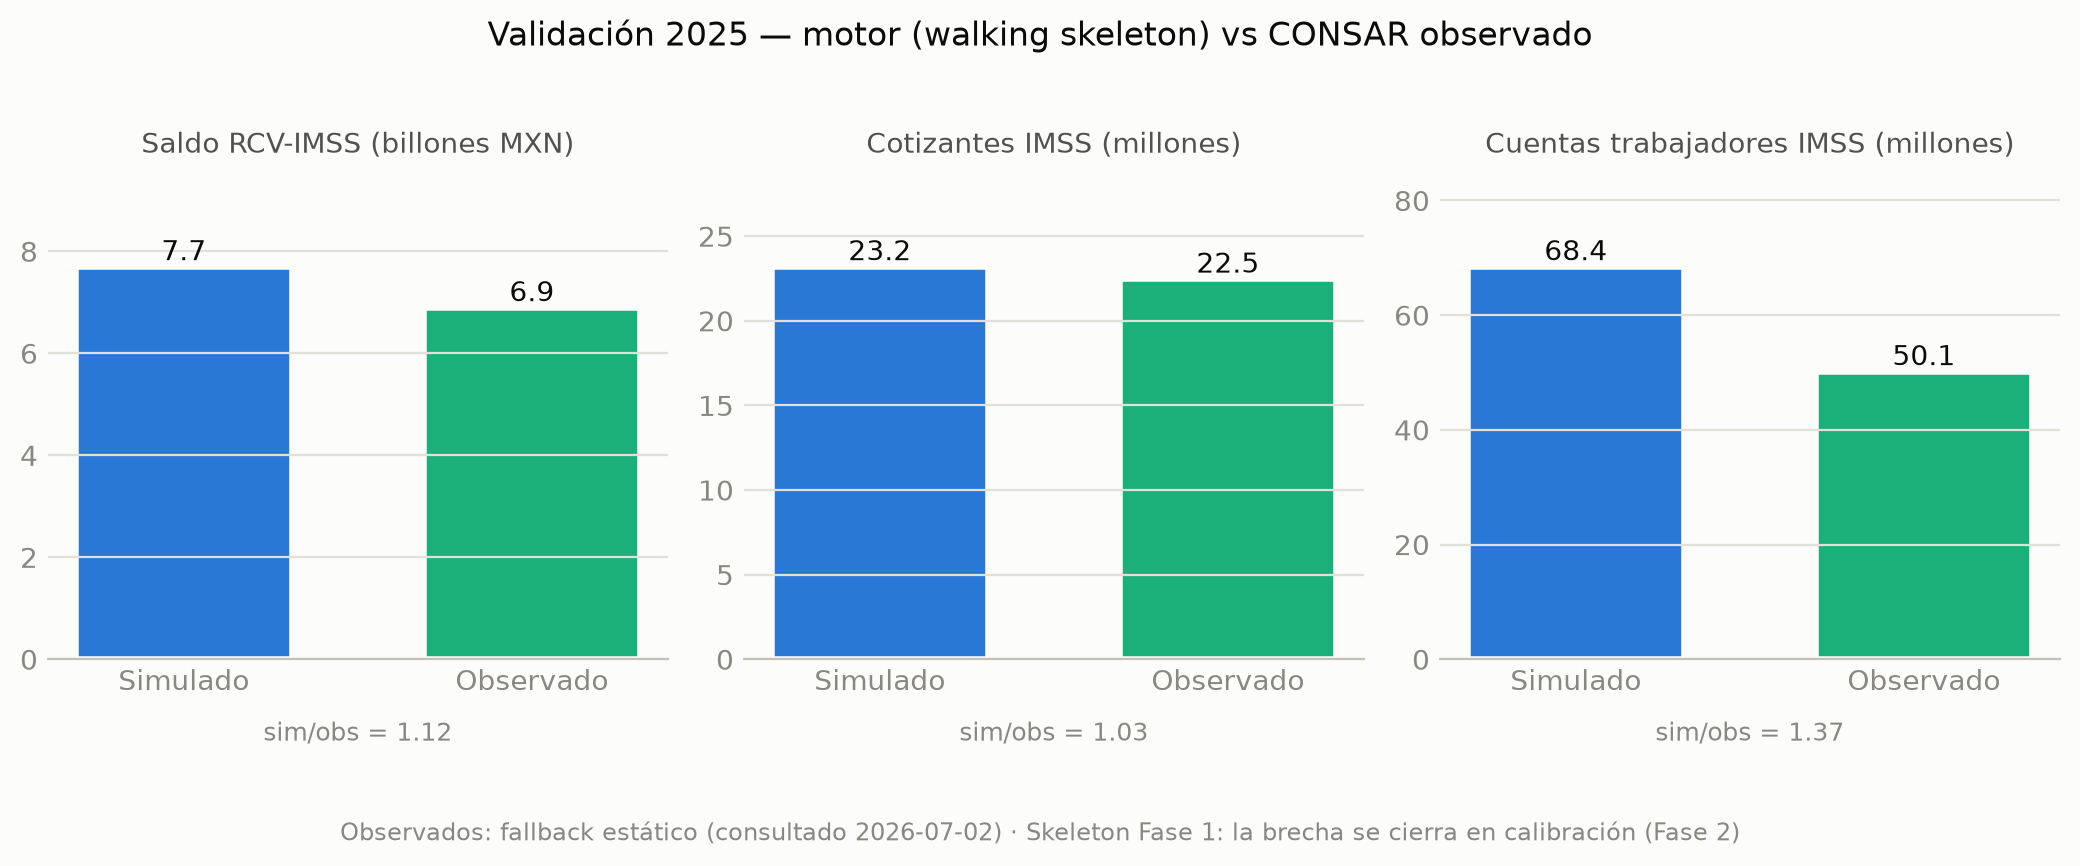

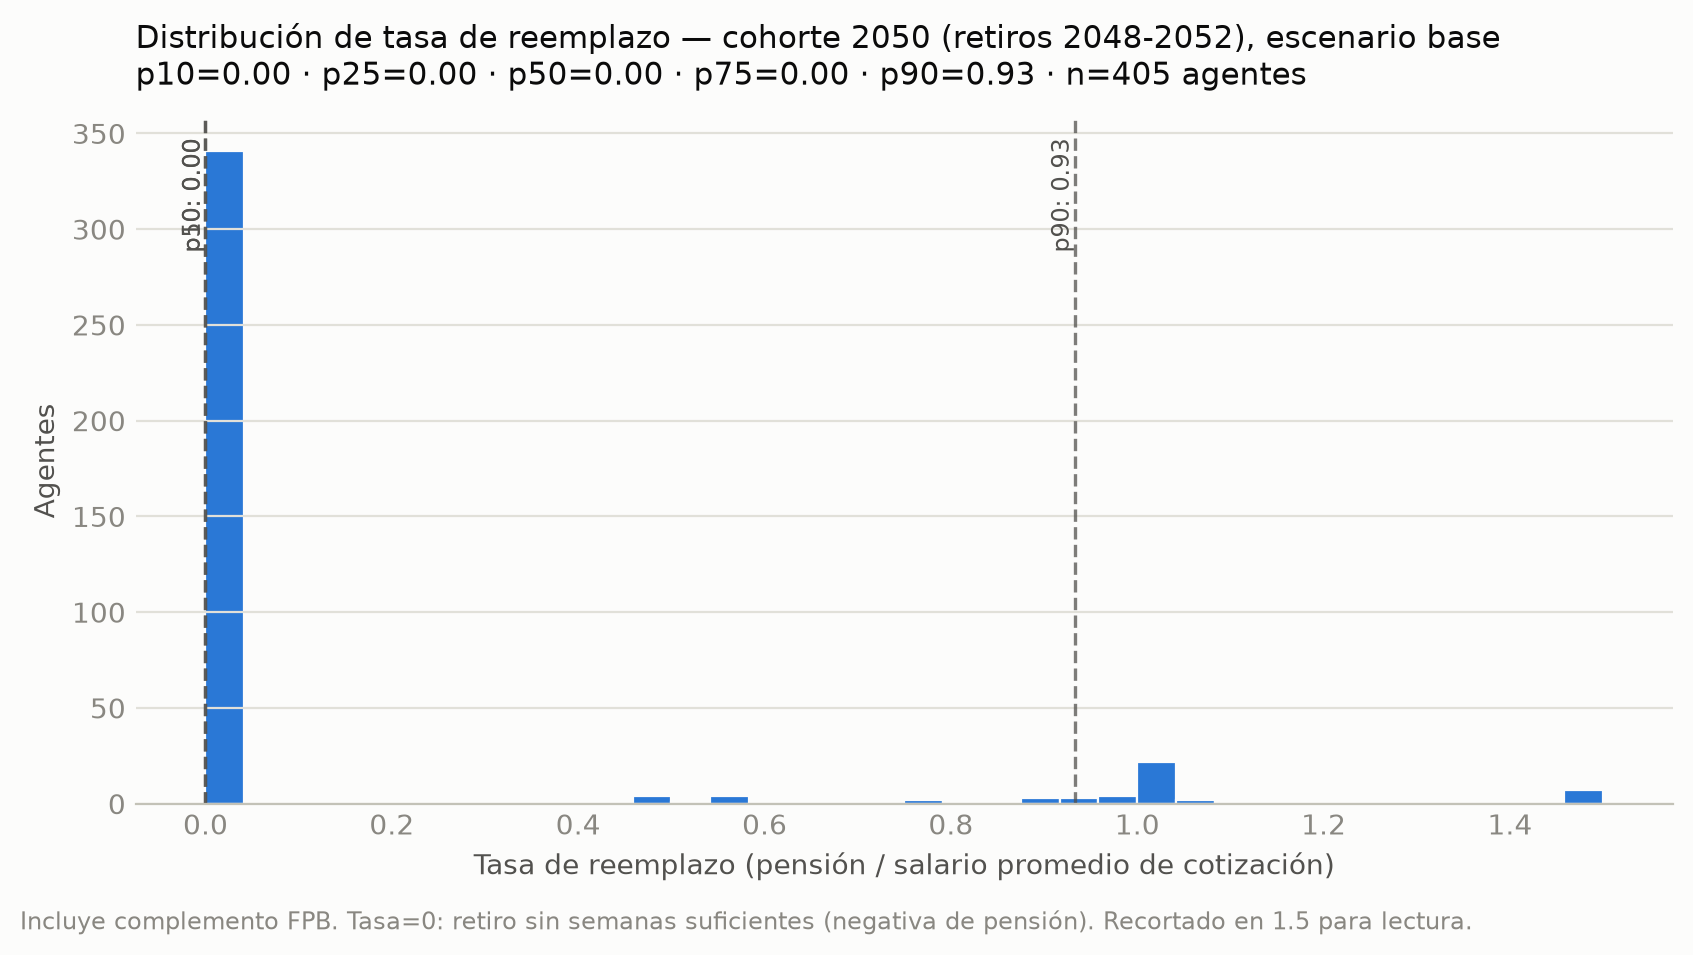

In [7]:
from IPython.display import Image, display

from motor import figuras
from motor.validacion import comparar

df_val = comparar(res.validacion, usar_api=False)

fig_val = SALIDA_LIGERA / "repro_fig_validacion_2025.png"
fig_tr = SALIDA_LIGERA / "repro_fig_tasa_reemplazo_2050.png"
figuras.figura_validacion(df_val, fig_val)
figuras.figura_tasa_reemplazo(res.agentes, fig_tr)
print("figuras regeneradas con la corrida ligera → motor/outputs/ (gitignorado):")
display(Image(str(fig_val)))
display(Image(str(fig_tr)))


In [8]:
tr_cot = ret.loc[ret["anios_formal"] > 0, "tasa_reemplazo"]
masa_cero_ligera = 100 * (tr_cot == 0).mean()

maestra = pd.read_csv(RESULTADOS / "tabla_maestra_masa_cero.csv")
fila_a = maestra[maestra["denominador"] == "a_anios_formal_gt0"].iloc[0]
pcts = pd.read_csv(RESULTADOS / "tr_percentiles.csv").set_index("percentil")

comp = pd.DataFrame([
    {"metrica": "masa en TR=0 (% de retirados que cotizaron)",
     "ligera_5k_1sem": round(masa_cero_ligera, 2),
     "citable_100kx5": fila_a["masa_en_cero_pct"],
     "ic95_citable": fila_a["ic95_semiancho"]},
    {"metrica": "TR p50 (retirados que cotizaron)",
     "ligera_5k_1sem": round(float(np.percentile(tr_cot, 50)), 4),
     "citable_100kx5": pcts.loc["p50", "tr"],
     "ic95_citable": pcts.loc["p50", "ic95_semiancho"]},
    {"metrica": "TR p90 (retirados que cotizaron)",
     "ligera_5k_1sem": round(float(np.percentile(tr_cot, 90)), 4),
     "citable_100kx5": pcts.loc["p90", "tr"],
     "ic95_citable": pcts.loc["p90", "ic95_semiancho"]},
])
comp["dif_abs"] = (comp["ligera_5k_1sem"] - comp["citable_100kx5"]).abs()
print("comparación ligera (5k × 1 semilla) vs citable (100k × 5 semillas):")
print(comp.to_string(index=False))

# cotas de cordura, holgadas por diseño: a 5k el error muestral domina;
# romperlas señala un cambio de mecánica, no ruido
assert comp.loc[0, "dif_abs"] < 10.0, "masa en cero se movió > 10 pp"
assert (comp.loc[1:, "dif_abs"] < 0.10).all(), "percentiles de TR se movieron > 0.10"
print("\ncotas de cordura: OK (las diferencias son ruido muestral esperado a 5k)")

print("\ncobertura citable (resultados_finales/cobertura.csv):")
cob = pd.read_csv(RESULTADOS / "cobertura.csv")
print(cob[["etiqueta", "pct_retirados", "ic95_semiancho"]].to_string(index=False))


comparación ligera (5k × 1 semilla) vs citable (100k × 5 semillas):
                                    metrica  ligera_5k_1sem  citable_100kx5  ic95_citable  dif_abs
masa en TR=0 (% de retirados que cotizaron)           83.03           84.25          0.14     1.22
           TR p50 (retirados que cotizaron)            0.00            0.00          0.00     0.00
           TR p90 (retirados que cotizaron)            1.00            1.00          0.00     0.00

cotas de cordura: OK (las diferencias son ruido muestral esperado a 5k)

cobertura citable (resultados_finales/cobertura.csv):
                             etiqueta  pct_retirados  ic95_semiancho
           Pensión contributiva plena           0.81            0.02
       Contributiva + complemento FPB           4.15            0.07
             Pensión garantizada (PG)           9.41            0.10
Sin pensión (saldo en una exhibición)          76.84            0.14
                 Nunca cotizó al IMSS           8.80           

artefactos citables versionados (resultados_finales/, 100k × 5 semillas):


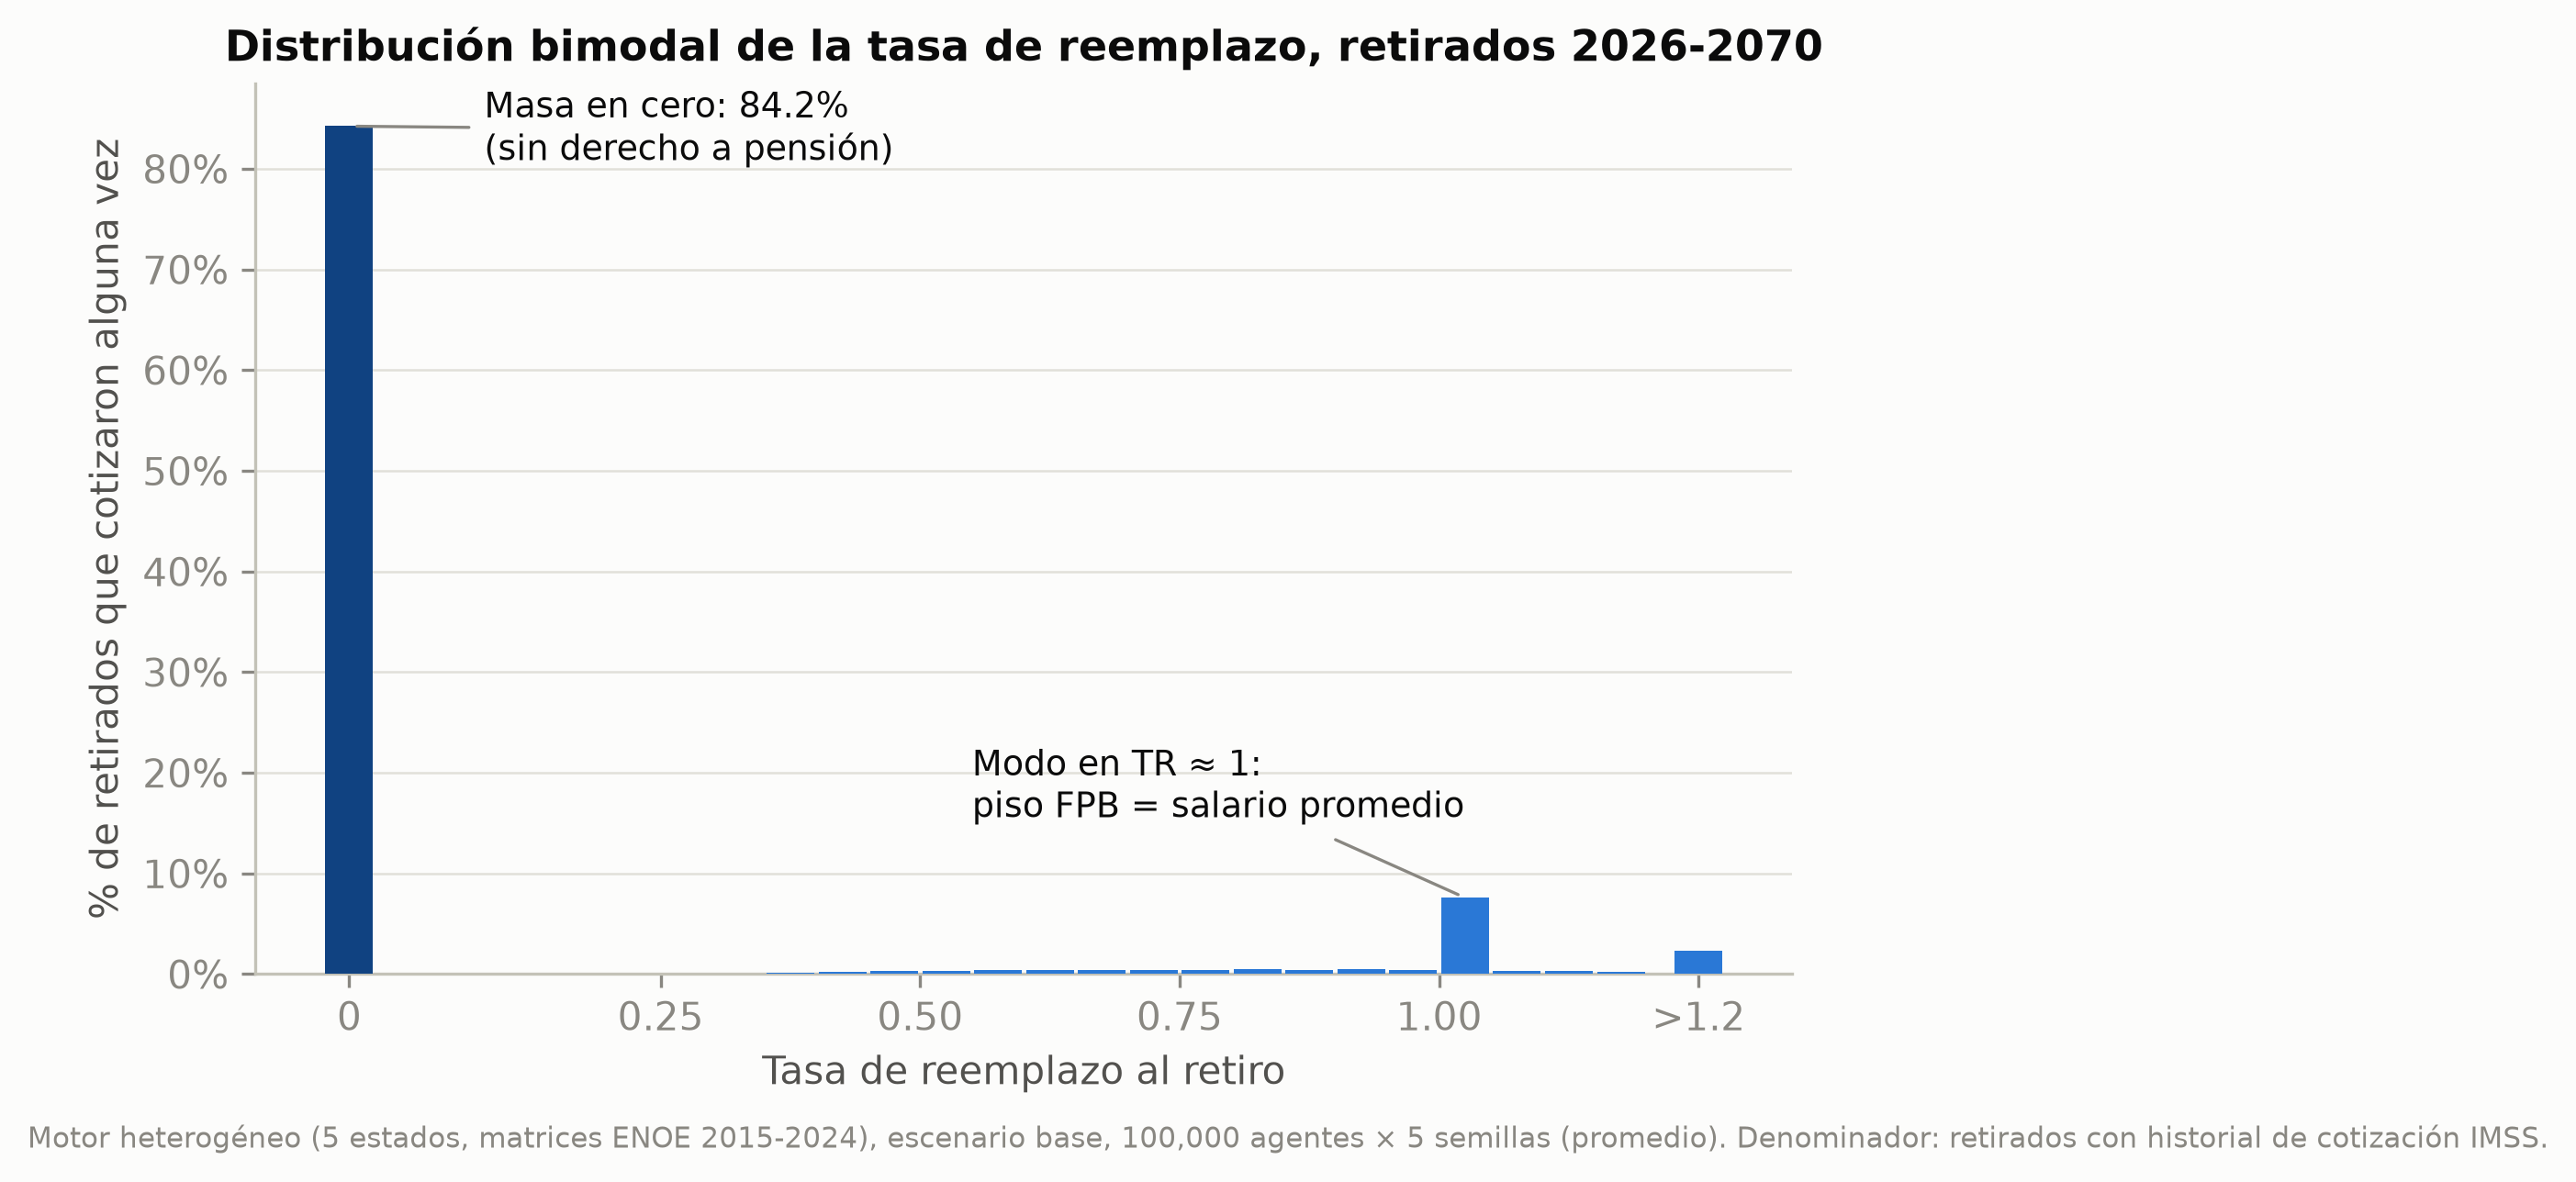

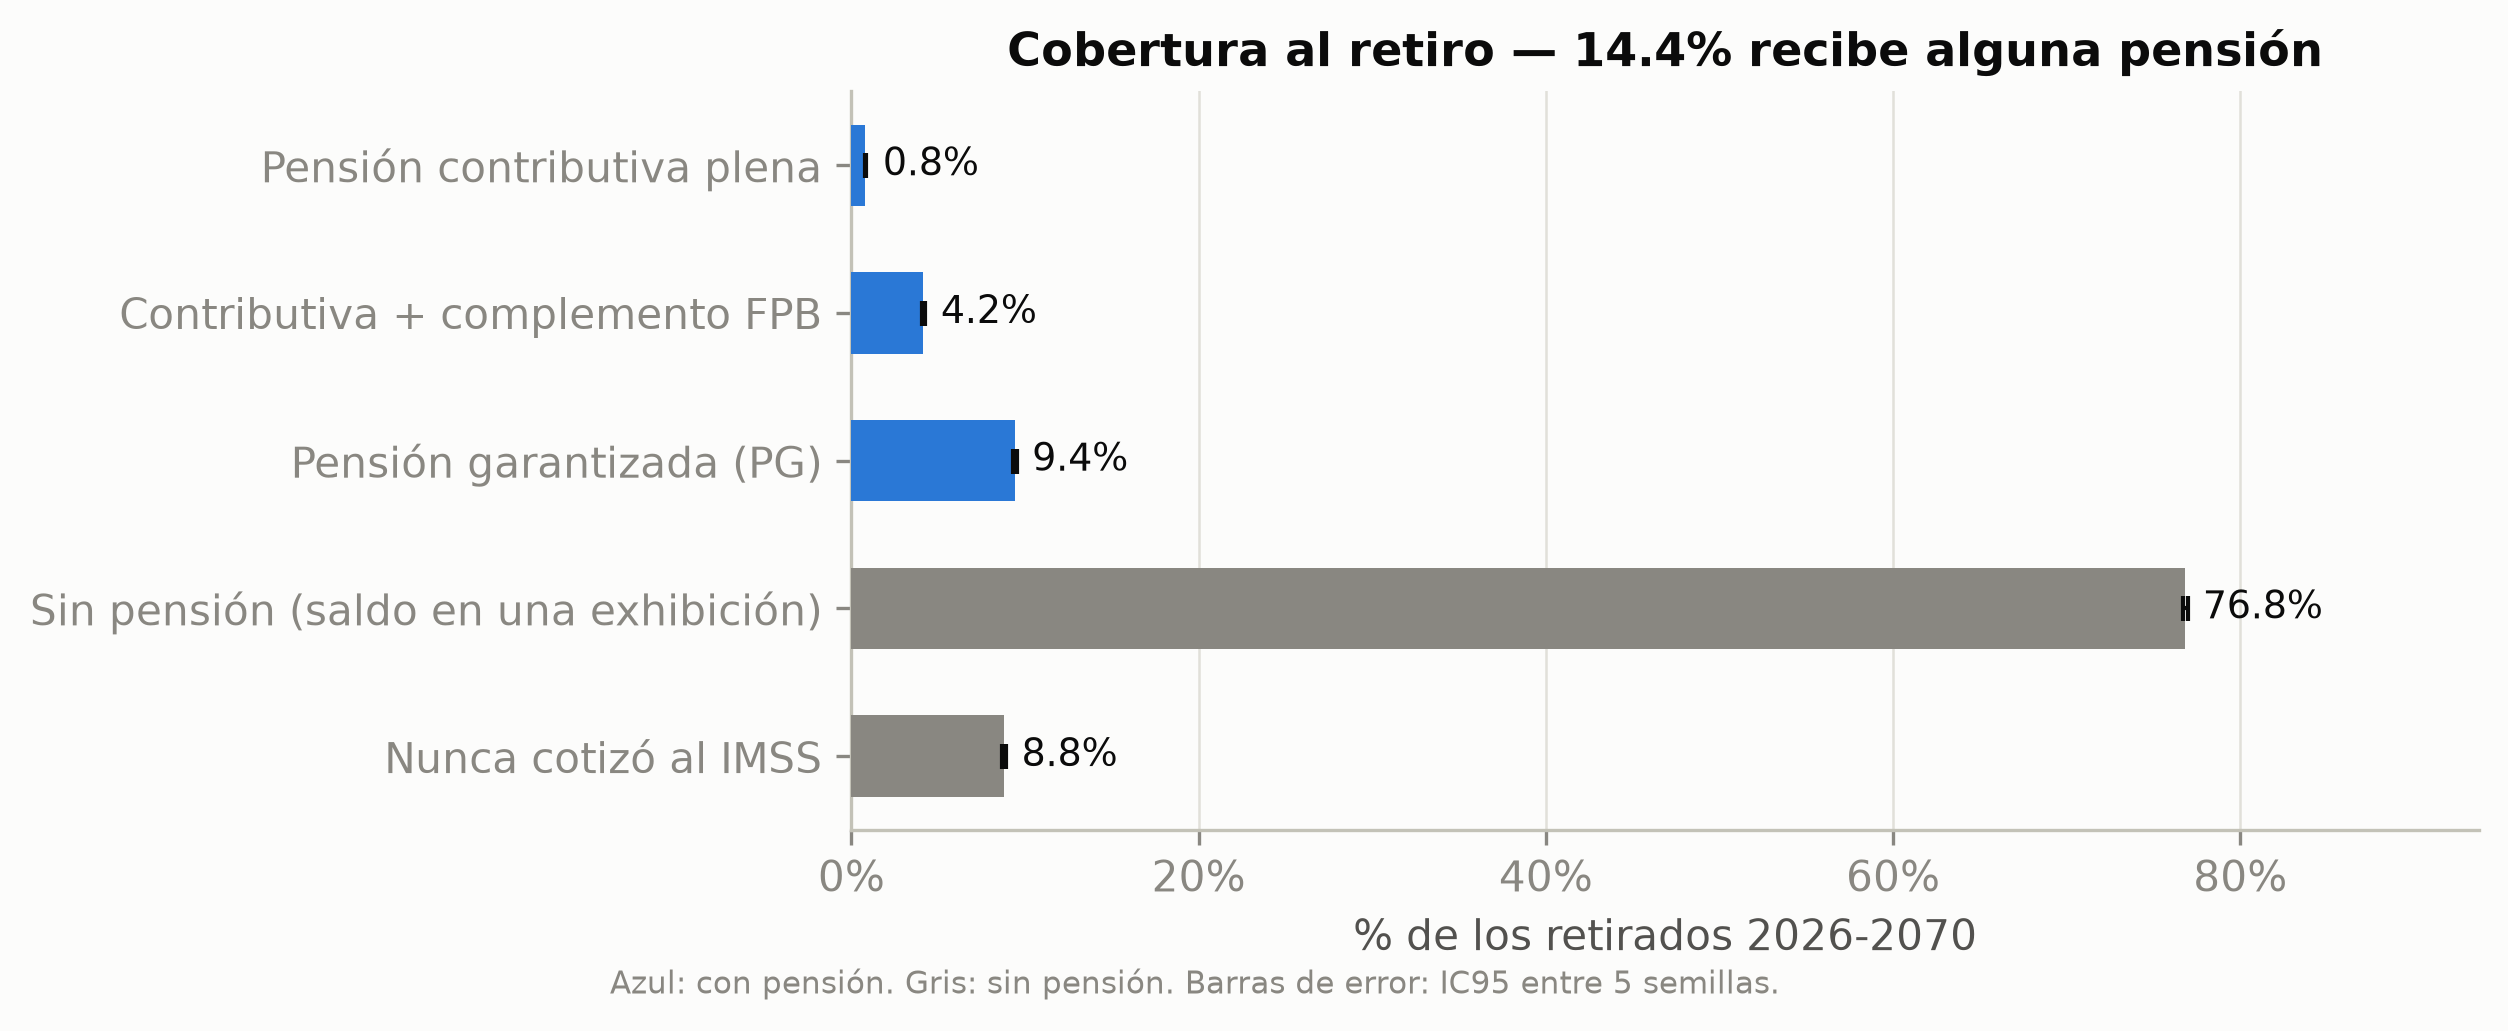

In [9]:
print("artefactos citables versionados (resultados_finales/, 100k × 5 semillas):")
display(Image(str(RESULTADOS / "fig_tr_distribucion.png")))
display(Image(str(RESULTADOS / "fig_cobertura.png")))


## 6. Anclajes de validación

La bisagra de credibilidad del motor: **reproducir el presente observado antes
de proyectar 45 años**. Los tres anclajes comparan agregados simulados 2025
contra observados (CONSAR/IMSS; fallback estático documentado en
`motor/datos.py`):

1. **Saldo RCV-IMSS** (billones MXN)
2. **Cotizantes IMSS** (millones)
3. **Cuentas de trabajadores IMSS** (millones)

La celda recalcula los tres con la corrida ligera y los contrasta con los
valores citables versionados (`revalidacion_brecha1.csv`, motor heterogéneo,
3 semillas) y con el anclaje transversal 2025 de la corrida a escala
(`checks_consistencia.csv`).


In [10]:
print(f"anclajes de la corrida ligera (5k, semilla {SEMILLA}):")
print(df_val.round(4).to_string(index=False))
print(f"fuente de observados: {df_val.attrs['fuente_observados']}")
assert df_val["razon_sim_obs"].between(0.8, 1.5).all(), \
    "razón sim/obs fuera del rango sano [0.8, 1.5]"

reval = pd.read_csv(AQUI / "revalidacion_brecha1.csv")
het = reval[(reval["bloque"] == "1_ratios") & (reval["regimen"] == "B_heterogeneo")]
print("\nanclajes citables (motor heterogéneo, revalidacion_brecha1.csv):")
print(het[["semilla", "ratio_saldo", "ratio_cotizantes", "ratio_cuentas"]]
      .to_string(index=False))
print(f"ratio de saldo promedio entre semillas: {het['ratio_saldo'].mean():.3f}")

checks = pd.read_csv(RESULTADOS / "checks_consistencia.csv")
trans = checks[checks["check"].str.startswith("transversal_2025")]
print("\nanclaje transversal 2025 — corrida 100k vs estacionaria anclada "
      "(puntos porcentuales):")
print(trans[["check", "valor", "referencia_5k", "dif_pp"]].to_string(index=False))
print(f"desviación máxima: {trans['dif_pp'].abs().max():.3f} pp")


anclajes de la corrida ligera (5k, semilla 20260701):
                             metrica  simulado  observado  razon_sim_obs
       Saldo RCV-IMSS (billones MXN)    7.6950     6.8913         1.1166
          Cotizantes IMSS (millones)   23.1866    22.4515         1.0327
Cuentas trabajadores IMSS (millones)   68.4267    50.1253         1.3651
fuente de observados: fallback estático (consultado 2026-07-02)

anclajes citables (motor heterogéneo, revalidacion_brecha1.csv):
 semilla  ratio_saldo  ratio_cotizantes  ratio_cuentas
20260701       1.1166            1.0327         1.3651
20260702       1.1508            1.0351         1.3648
20260703       1.1393            1.0616         1.3770
ratio de saldo promedio entre semillas: 1.136

anclaje transversal 2025 — corrida 100k vs estacionaria anclada (puntos porcentuales):
                         check  valor  referencia_5k  dif_pp
  transversal_2025_formal_IMSS 23.900         24.456  -0.556
transversal_2025_formal_ISSSTE  4.916          4

## 7. Metadata de reproducibilidad

Entorno con el que se ejecutó este notebook, semillas y referencia de release.
Las versiones exactas de **todas** las dependencias (con hashes) están
congeladas en `requirements-dev.txt`; el CI instala ese mismo lockfile.


In [11]:
import platform
from importlib.metadata import version as _v

tabla_versiones = pd.DataFrame([
    {"componente": "Python", "version": platform.python_version()},
    {"componente": "numpy", "version": _v("numpy")},
    {"componente": "pandas", "version": _v("pandas")},
    {"componente": "matplotlib", "version": _v("matplotlib")},
    {"componente": "pyyaml", "version": _v("pyyaml")},
    {"componente": "datos-mexico (SDK)", "version": _v("datos-mexico")},
])
print(tabla_versiones.to_string(index=False))

print(f"\nsemilla de la corrida ligera: {SEMILLA} (motor/config.yaml)")
print("semillas de la corrida citable: 20260701-20260705 "
      "(resultados_finales/metadata_corrida.csv)")
print(f"commit ejecutado: {commit}")
print("release de referencia: v1.0-amafore (placeholder; el tag del envío "
      "fijará el commit exacto citado en el paper)")


        componente version
            Python 3.12.12
             numpy   2.5.0
            pandas   3.0.3
        matplotlib  3.11.0
            pyyaml   6.0.3
datos-mexico (SDK)   0.2.1

semilla de la corrida ligera: 20260701 (motor/config.yaml)
semillas de la corrida citable: 20260701-20260705 (resultados_finales/metadata_corrida.csv)
commit ejecutado: 8d2cfa2
release de referencia: v1.0-amafore (placeholder; el tag del envío fijará el commit exacto citado en el paper)


---

**Qué debe esperar quien dictamina.** En modo ligero, todas las celdas de
verificación pasan sin red y sin microdatos locales: invariantes de las
matrices versionadas (§3), check contable y mecánica del motor (§4), cotas de
cordura ligera-vs-citable (§5) y los tres anclajes (§6). Con
`EJECUTAR_DESCARGA` y `EJECUTAR_ESTIMACION` activados, la §2-§3 regeneran las
matrices desde microdatos públicos; con `EJECUTAR_CORRIDA_COMPLETA`, la §4
regenera los artefactos citables de `resultados_finales/` — en la misma
plataforma, la regeneración es determinista por semilla fija (`git diff` debe
salir limpio; entre plataformas distintas puede haber diferencias de redondeo
flotante de último bit, ver `tests/motor/test_motor.py`).
